# Computational Laboratory 4CCP1300 Assessment

#### Module coordinator: Mark Mitchison (mark.mitchison@kcl.ac.uk)

## Assessment information

In this Jupyter notebook, you will find the guidelines and questions to be completed for the assignment for the computational modeling course. The assignment is due by **20th March 2026 at 23:59 GMT**, and must be submitted via Turnitin on KEATS. This means that you must download this completed jupyter notebook from CoCalc, save it locally, and then submit it via KEATS. You can download your completed jupyter notebook from CoCalc once completed, e.g. by clicking on the menu option above: `File > Download File` and then confirming by clicking the `Download` button. Remember that submitting at the last moment might put you at risk of unexpected events (failing internet connection or other problems), so plan your time, and aim to submit well BEFORE the deadline. A section on KEATS will be opened soon to allow for your online submissions there. **Please note that the completed Jupyter notebooks should be submitted directly (this file, with file extension `.ipynb`), NOT a pdf, html, or text document**, so that the code can be run by the markers and checked for accuracy of the code. Submitted work will be checked for similarity of the submitted notebooks to other students or AI-generated content: plagiarism will not be tolerated. Note that the basic similarity measure on TurnItIn will be high, due to the same questions in each notebook, and will just be used as a guide, so don't worry if this crude measure is high. 

This document will provide a set of three problems that you will need to solve by using the knowledge built up from the notebooks and exercises completed during the course. You can revisit previous notebooks to refresh your knowledge from the course. The various parts of the problems should be submitted in separate code cells under each subsection of the questions. These cells should generate the results, and will build on the work of previous cells. Furthermore, text cells should be included with discussion and more information about each question where required. Note that the code itself \(Python cells\) will be marked, so please follow good coding practices outlined in the lectures (appropriate comments in the code, and clean, consistent and well structured code, with output appropriately formatted for readability\). **Note that all cells should execute properly without error messages given.** To check this in CoCalc, you should go in the menu above to `Kernel > Restart Kernel > Restart & Run All Cells`, and ensure that the correct output is generated by all of your code cells for each question. **Finally, please fill out your name, k-number and email address below**, as this is how your marks will be returned to you. Good Luck!


### Student Name: \[Caleb Levell\]

### k\-number: \[K25036522\]

### Email address: \[K25036522@kcl.ac.uk\]



## Problem 1: Molecular conformers

A molecular conformer is a particular shape or atomic arrangement that a molecule can adopt. Often molecules will flip between these two arrangements of their atoms. The aim in this problem is to model the changes in the numbers of molecules in different shapes (conformers) over a period of time. 

We assume that there are two conformers of a particular molecule which we want to model, conformer $A$ and conformer $B$, and the total number of molecules is fixed, so that $n_A + n_B$ remains the same. We assume that every hour, 20% of the current population of conformer $A$ will turn into conformer $B$. However, there is a chance of also transitioning in the other direction, and so each hour, 10% of the molecules in conformer $B$ turn back into conformer $A$. We assume that initially, there are 150 '$A$ molecules' and 150 '$B$ molecules'. We also assume that the changes in populations take place in discrete time intervals on the hour, each hour.

a) We can write the number of $A$-molecules ($n_A$) and $B$-molecules ($n_B$) as a vector each hour, $$ \begin{bmatrix} n_A \\ n_B \end{bmatrix}.$$ Furthermore, we can recast the problem of finding the vector from one hour to the next, as a single matrix equation, with a linear system of equations. By acting the initial vector of populations on a $2 \times 2$ matrix of fixed probabilities, indicating the proportion of molecules which transition between states or remain in the current state, you should be able to find the vector of populations in the second hour to be $n_A=135$ and $n_B=165$.

**Write a code cell below, to initialize a numpy array of the appropriate $2 \times 2$ matrix of probabilities assigned to the variable `P`, and the vector of current $A$ and $B$ populations, assigned to the variable `pop`, which should be initialized to $(150, 150)$. Calculate the matrix multiplication of `P` and the vector `pop` (use the `numpy` module to help), and therefore print out what the population of each type is after one hour (which should be $n_A = 135$ and $n_B=165$). Finally, have the code test whether the matrix `P` is a symmetric matrix or not, and print out a statement about this.** [8 marks]

In [47]:
# initially, we have nA = nA and nB = nB
# after 1 hour, nA(t=1) = 0.8nA + 0.1nB and nB(t=1) = 0.2nA + 0.9nB

import numpy as np

P = np.array([[0.8, 0.1],    # therefore the matrix of probabilities P is...
            [0.2, 0.9]])

pop = np.array([150, 150])   # vector initially

fizz = P @ pop        # matrix multiplication of P and pop

print('Population after 1 hour:')
print('n_A =', fizz[0])
print('n_B =', fizz[1])      # population of each type after 1 hour

if np.allclose(P,P.T):
    print('Matrix P is symmetric')
else:
    print('Matrix P is not symmetric')  # P is symmetric if P and P.T are equal, so we test for this with the allclose function

Population after 1 hour:
n_A = 135.0
n_B = 165.0
Matrix P is not symmetric


b) We are particularly interested in what happens after a long time - are there a steady number of $A$- vs. $B$-molecules, or does one conformer win out? If it is a 'steady state' (when the populations settle down to a constant over time), then what are these steady populations? Note that the transition probabilities remain the same each hour, so we can use the same probability matrix, `P`, and use it to update the populations many times. 

**Set up a loop in the code cell below, to find out what the populations are 72 hours after the initial condition. Each iteration, also check that the total number of molecules ($n_A + n_B$) is conserved, and equal to the original number (300, to within reasonable numerical precision). Write out the final number of $A-$ and $B-$molecules. Is this a stable number, or does it change after another day?** [6 marks]

In [48]:
import numpy as np

P = np.array([[0.8, 0.1],    # remember P and pop
            [0.2, 0.9]])

pop = np.array([150, 150])

for i in range(72):    # set up loop over 72 hours and find new vector (n_A, n_B) every iteration
    pop = P @ pop     
    
# check n_A and n_B add up to 300 for every iteration. using np.isclose makes sure they are the same within reasonable precision    
    total = pop[0] + pop[1]    
    if not np.isclose(total, 300):                                    
        print('Uh oh, the number of molecules has not been conerved')
        
old_pop = pop.copy()    # storing the value of pop after 72 hours as i want to check if its stable later        

# final populations:

print('After 72 hours')
print('n_A =', pop[0])
print('n_B =', pop[1])

# after another day...
for i in range(24):  
        pop = P @ pop

print("After another 24 hours:")
print("n_A =", pop[0])
print("n_B =", pop[1])

# is it stable/did it change after another day?
if np.allclose(pop, old_pop):    # comparing values after extra 24 hours to values after initial 72 hours
    print('n_A and n_B are stable')
else:
    print('n_A and n_B are not stable')

After 72 hours
n_A = 100.00000000035186
n_B = 199.99999999964894
After another 24 hours:
n_A = 100.0000000000004
n_B = 200.00000000000057
n_A and n_B are stable


c) This long-time 'steady-state' behaviour can calculated directly, since we know that any vector where the application of a matrix results only in only a scaling of this vector (leaving the relative magnitudes of the elements of the vector unchanged) must be an eigenvector of the matrix. Specifically, if the populations are steady and not growing overall, the eigenvalue corresponding to this eigenvector must also be equal to 1. (Check the definition of an eigenvector to make sure you are happy with this logic). 

**In the code cell below, diagonalize the matrix `P`, and find the eigenvector corresponding to the eigenvalue equal to 1. Note that this eigenvector is not normalized corresponding to the initial conditions we set (i.e. that the total population is 300 at every time). Find and print out the factor that the eigenvector should be multiplied by, in order to ensure that the long-time steady state populations of $A$- and $B$-molecules matches the values obtained in part c). This number should be printed out to 4 decimal places.**

Note that you should use the `numpy` or `scipy` modules in order to do this diagonalization, though it may be worth checking that your code is doing what it should by comparing to a pen-and-paper diagonalization of the matrix. [6 marks]



In [49]:
import numpy as np

P = np.array([[0.8, 0.1],    
            [0.2, 0.9]])

evals, evecs = np.linalg.eig(P)   # diagonalise P / find eigenvalues (evals) and eigenvectors (evecs)

L = np.isclose(evals, 1.0)   # let L be the eigenalue 1
v = evecs[:, L]              # find the corresponding eigenvector to eigenvalue 1
print('The eigenvector corresponding to eigenvalue 1 is {0}'.format(v))

# finding the scale factor:
# x * v[0]+v[1] = 300  => x = 300/(v[0]+v[1]), where x is the factor to multipy the eigenvector by

x = 300/(v[0] + v[1])
x = np.round(x, 4)     # round to 4 d.p
print('The scaling factor is {0}'.format(x))

# just double checking x scales to the stable vector from b) (100,200)
pop = np.array([[100],
                [200]])
if np.allclose(pop, x*v):
    print('Hurray!')
else:
    print('Uh oh')

The eigenvector corresponding to eigenvalue 1 is [[-0.4472136 ]
 [-0.89442719]]
The scaling factor is [-223.6068]
Hurray!


## Problem 2: The logistic map

In this problem we are considering the logistic map, a very simple sequence with very non-trivial behaviour. It simply updates a (scalar) variable, such that its next value depends solely on its current value. The sequence has the following form:

$x_{n+1} = a \times x_n \times (1-x_n)$ ,

where $x_n$ is the current variable in the range $[0,1]$, $x_{n+1}$ is the next value in the sequence, and $a$ is the growth rate which we will consider to be in the range $[0,4]$. This is often used to model systems which grow under a constraint of a finite number of resources, where e.g. $x_n$ represents the fraction of the total possible population size at a particular time. Here, the population will grow according to $x_n$, but be constrained by the $(1-x_n)$ term when $x_n$ gets too large. When $x_n=0$, the population is zero, and when $x_n=1$, the population is at its maximum possible size.  Indeed, since the resources are limited, the expansion is also proportional to $(1-x_n)$ and if the civilization reaches the maximum population of $x=1$ it will have exhausted all its resources and then collapses to $x=0$. Note that compared to the problem above, this sequence has non-linear (quadratic) terms in $x_n$, which has a profound effect, especially in the long-time limiting behaviour. As a background to this problem, it may be helpful to watch the following video [here](https://www.youtube.com/watch?v=ovJcsL7vyrk&list=WL&index=74&t=0s).

a) **Write a function called `find_fix_point` in the code cell below, which takes as its arguments, the growth rate $a$, and an initial value for $x_0$. It should return the convergence point of the sequence. We assume in this problem that the sequence reaches a converged state after $n=100$ iterations, so that the convergence point $x^*$ can be approximated by the $n=100$ element of the sequence ($x_{100}$).** [6 marks]

In [50]:
def find_fix_point(a, x0):    # x0 as an initial condition
    x = x0
    for n in range(100):
        x = a * x * (1-x)    # define sequence
    return x

b) We now want to consider how this 'fix point', $x^*$, varies for different growth rates, $a$, and different initial conditions, $x_0$. 

**In the code cell below, loop over $1000$ uniformly spaced growth rates in the interval between `a_init` and `a_final`. This means that `a=a_init` for the first cycle of your `for` loop, and `a = a_final` for the last cycle. For each value of $a$, we also want to loop over $50$ possible values for $x_0$ in the range [0,1]. However rather than these taken to be uniformly spaced, these initial conditions should be chosen at random, using the `numpy.random` module. Store all of the values for $x^*$ in an array (found using the function defined in part a), and make a scatter plot of $x^*$ against $a$, for $a$ (on the x-axis) in the range $1.5$ to $4$, with each point represented by a small black point. Be sure to always label your axes!** [9 marks]

Text(0.5, 1.0, 'Logistic Map!')

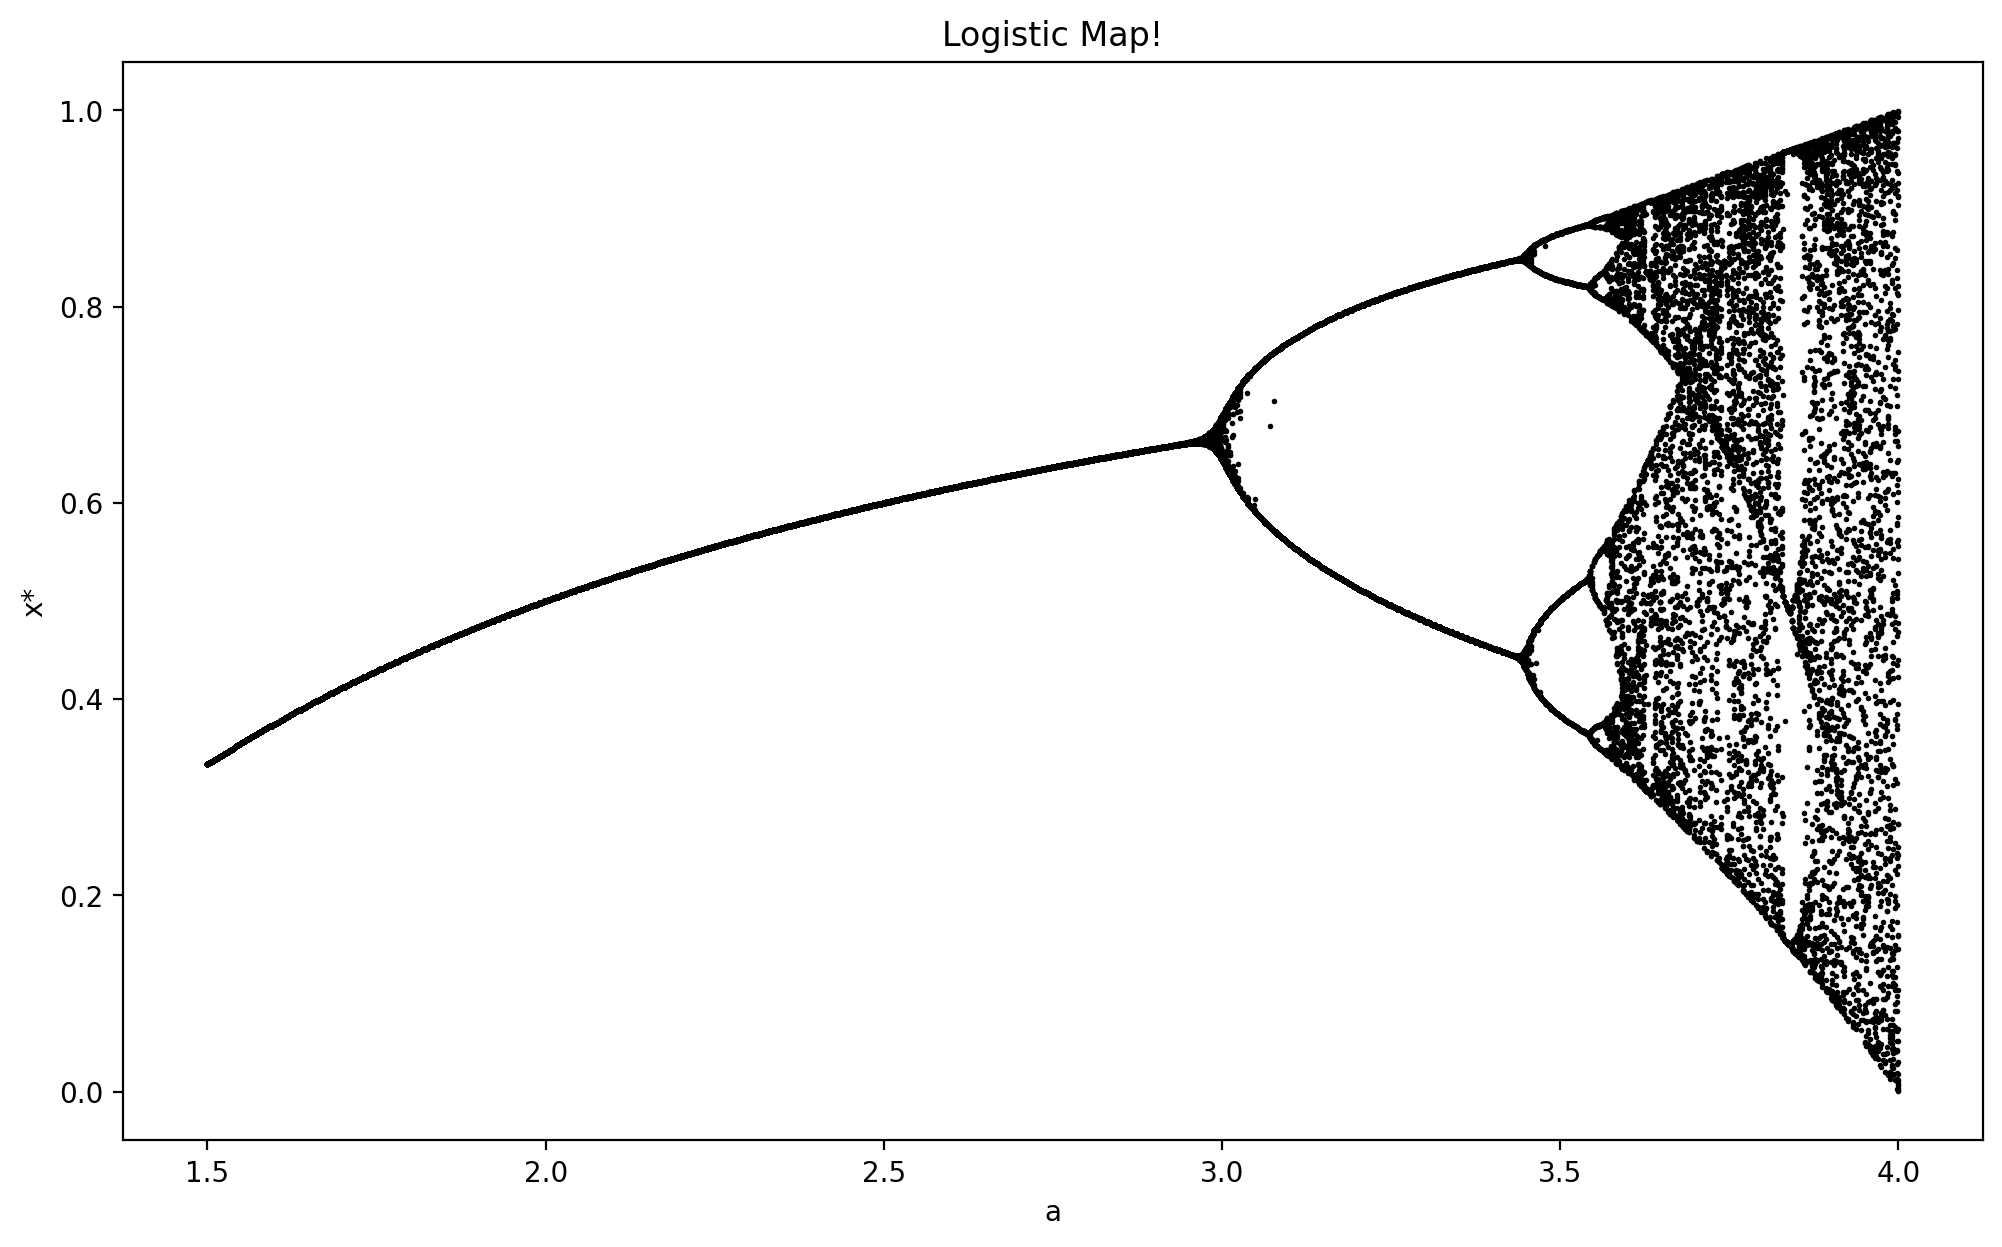

In [51]:
import numpy as np 
import matplotlib.pyplot as plt

a_init = 1.5    # set up range of a
a_final = 4

a_values = np.linspace(a_init, a_final, 1000)  # create uniformly spaced values of a

a_plot = []       # empty lists of a and x* to be filled with the values found by te function
x_plot = []

for a in a_values:
    x0_values = np.random.random(50)       # 50 x0 values for each a
    
    for x0 in x0_values:
        x_star = find_fix_point(a,x0)       # finds values of x* for all the as and x0s
        
        a_plot.append(a)
        x_plot.append(x_star)               # add each value of a and x*
        
a_plot = np.array(a_plot)
x_plot = np.array(x_plot)                   # make the lists into array so i'm doing what the question asked


plt.scatter(a_plot,x_plot,s=1,color='black')     # plot them i hope? and i need colour of course
plt.xlabel('a')
plt.ylabel('x*')
plt.title('Logistic Map!')
        

c) **Repeat the code of b) below, but now make a scatter plot of $x^*$ for $1000$ equally-spaced values of $a$ in the interval [3,4], and a similar plot for $a$ in the interval [3.5,3.8].** [2 marks]

Text(0.5, 1.0, 'Logistic Map! (version 2)')

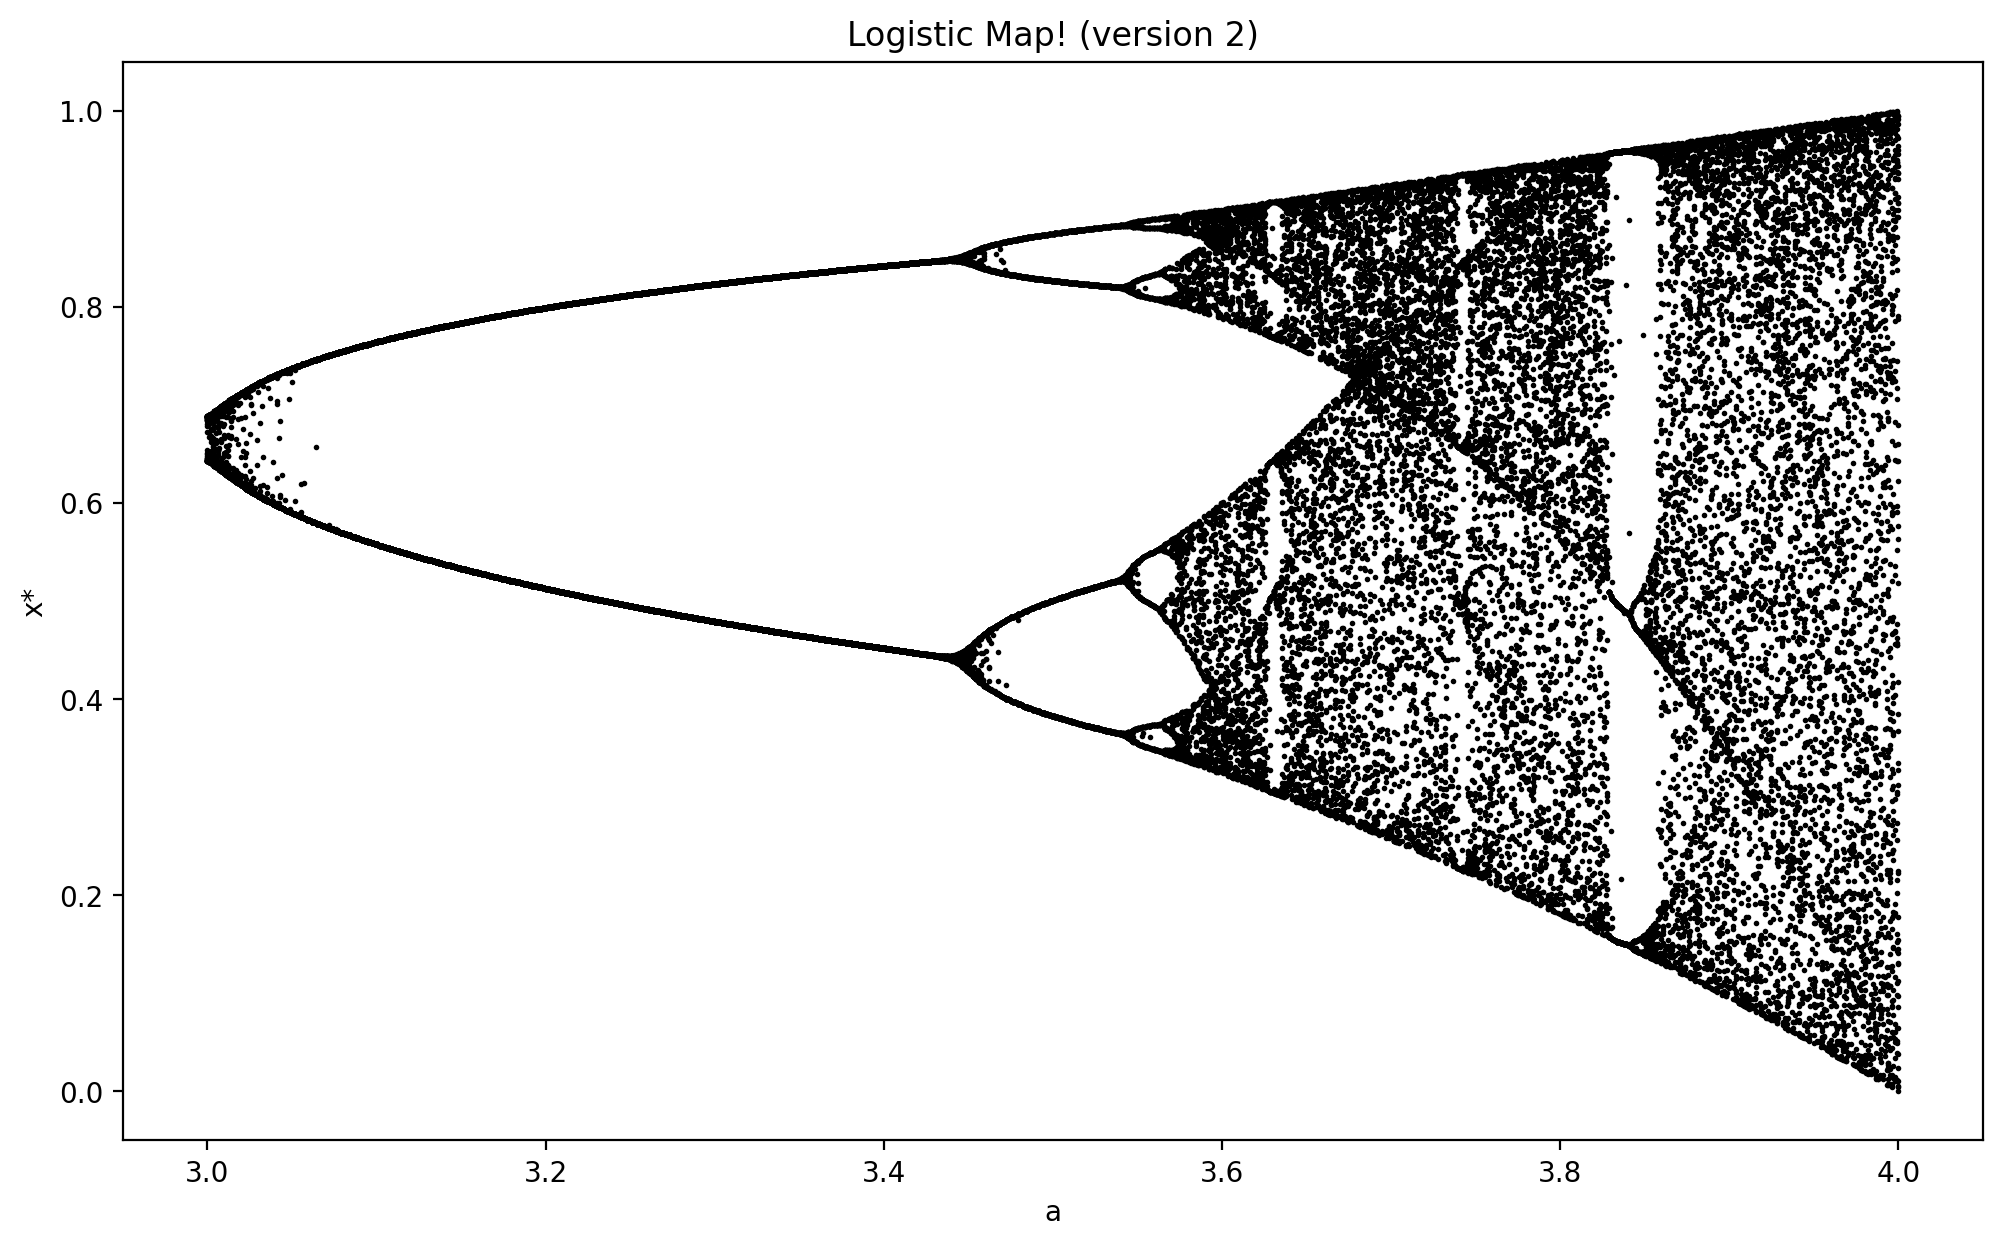

In [52]:
import numpy as np 
import matplotlib.pyplot as plt

a_init = 3    # set up (new) range of a
a_final = 4

a_values = np.linspace(a_init, a_final, 1000)  # create uniformly spaced values of a

a_plot = []       # empty lists of a and x* to be filled with the values found by te function
x_plot = []

for a in a_values:
    x0_values = np.random.random(50)       # 50 x0 values for each a
    
    for x0 in x0_values:
        x_star = find_fix_point(a,x0)       # finds values of x* for all the as and x0s
        
        a_plot.append(a)
        x_plot.append(x_star)               # add each value of a and x*
        
a_plot = np.array(a_plot)
x_plot = np.array(x_plot)                   # make the lists into array so i'm doing what the question asked


plt.scatter(a_plot,x_plot,s=1,color='black')     # plot them i hope? and i need colour of course
plt.xlabel('a')
plt.ylabel('x*')
plt.title('Logistic Map! (version 2)')
        

Text(0.5, 1.0, 'Logistic Map! (version 3)')

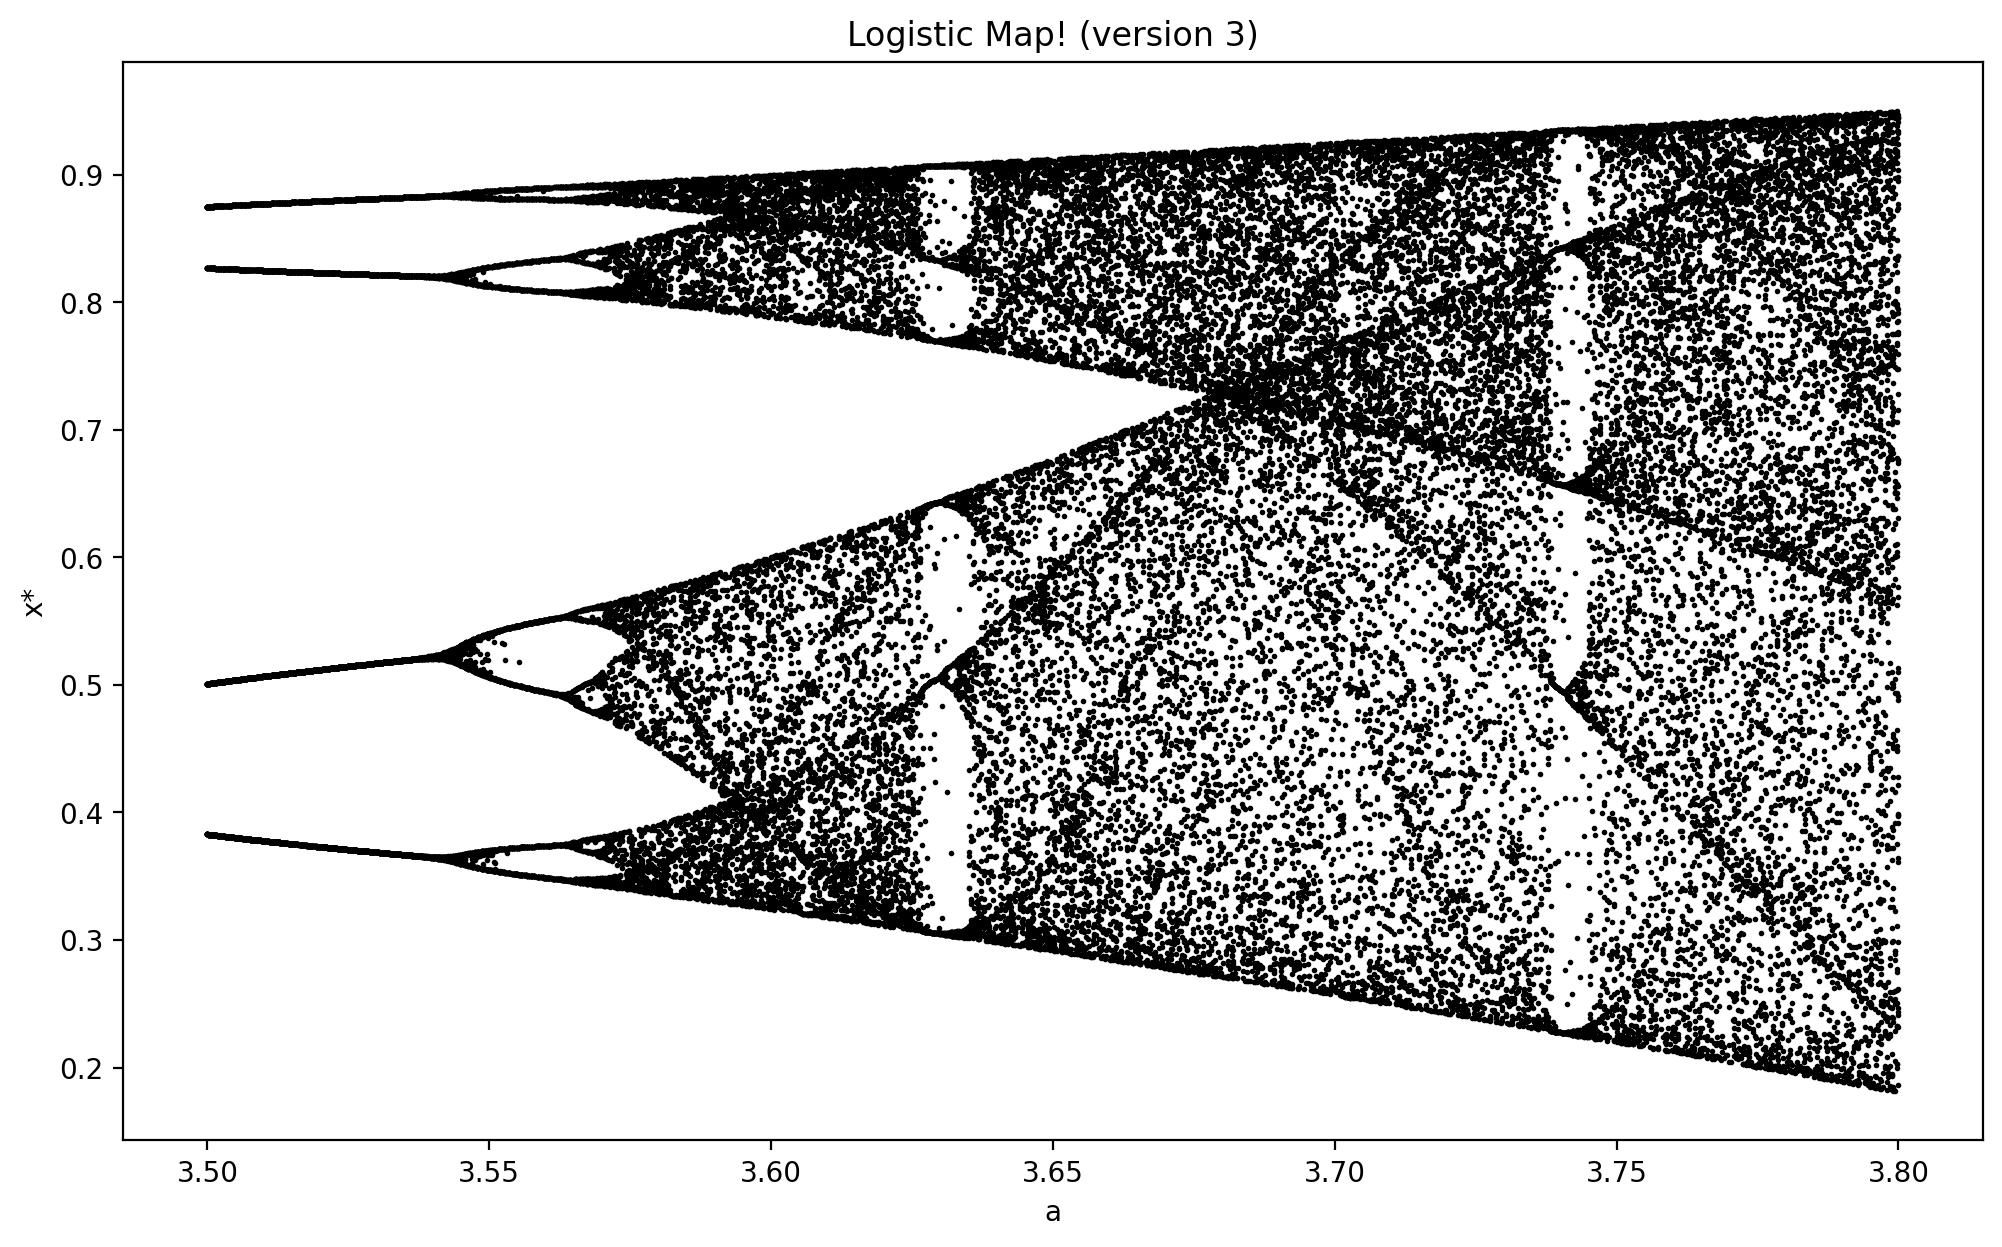

In [53]:
import numpy as np 
import matplotlib.pyplot as plt

a_init = 3.5    # set up range of a
a_final = 3.8

a_values = np.linspace(a_init, a_final, 1000)  # create uniformly spaced values of a

a_plot = []       # empty lists of a and x* to be filled with the values found by te function
x_plot = []

for a in a_values:
    x0_values = np.random.random(50)       # 50 x0 values for each a
    
    for x0 in x0_values:
        x_star = find_fix_point(a,x0)       # finds values of x* for all the as and x0s
        
        a_plot.append(a)
        x_plot.append(x_star)               # add each value of a and x*
        
a_plot = np.array(a_plot)
x_plot = np.array(x_plot)                   # make the lists into array so i'm doing what the question asked


plt.scatter(a_plot,x_plot,s=1,color='black')     # plot them i hope? and i need colour of course
plt.xlabel('a')
plt.ylabel('x*')
plt.title('Logistic Map! (version 3)')
        

d) **Discuss the results obtained in a Markdown cell. For which values of $a$ do you obtain more than one fixed point? Discuss the observed trend as $a$ is increased, and the consequence of the accumulation of fixed points for the stability of a growing population. Why are the long-time trends of this sequence so different to the previous question.** [2 marks]

- There is more than one fixed point for values of a greater than 3
- When a is low \(less than/equal to 3\), there is one fixed point so we have a stable population. When a is moderate \(ie around 3 to 3.5\), the number of fixed points for each value of a double periodically \(from 2 to 4 to 8…\) , suggesting the population oscillates between multiple stable populations. When a is high \(3.6\+\), there are many fixed points and the sequence becomes chaotic, so the population is very unstable.
- The long\-time trends of this sequence are so different because we had just two initial conditions \(a and x0\). Here, there are so many values of a and x0 so the long\-time trend doesn't just converge to a fixed point anymore.



usi## Problem 3: Projectile motion

One of the big challenges in mathematical physics is the solution to differential equations, such as Newtons equations. In this problem, we aim to simulate the motion of a projectile under the force of gravity. While simple 'free' projectiles like this can be solved analytically (with the 'constant acceleration' equations), we are going to instead use the Euler method to numerically integrate these equations in time to follow the trajectory of the projectile, and so these analytic constant acceleration equations should *not* be used.

In order to do this, we note that we can decouple the $x$ (horizontal) and $y$ (vertical) motion. We therefore aim to end up with two arrays for the $x$-coordinates and $y$-coordinates for each time step that we consider (as well as another set of arrays for the components of the velocity). Finally, to solve differential equations, we will need to specify an initial condition, i.e. the initial $x$ and $y$ position for the projectile, as well as the initial velocity in each direction. Considering the propagation in the $y$-direction (the $x$ direction is simple, as there is no acceleration and the velocity is therefore constant), we can write the expression for the propagation of the coupled $y$-position and $y$-velocity of the particle as

$\dot{y}(t + \Delta t) = \dot{y}(t) - \Delta t \times g$

$y(t + \Delta t) = y(t) + \Delta t \times \dot{y}(t)$

With these two equations, we can predict the position and velocity of the particle at the next time point, from knowledge of the position and velocity at the previous time point.

a) **Initialise variables denoting the timestep for the integration, `dt`, the acceleration due to gravity, `g=9.8`ms$^{-2}$, and the maximum time to integrate, `t_max`. Calculate the number of timesteps required simulate this maximum time, and initialize numpy arrays to hold the $x$- and $y$- positions and velocities for each time step. It will also be worth initializing variables to store the initial speed, height and angle of the trajectory rather than hard coding them, so that these can be simply changed later on.**

**Initialize the projectile as starting at ground level, and fired at a speed of 100ms$^{-1}$ at an angle of $30^{\circ}$ above ground level, choosing `dt=0.01` seconds. Print out the maximum height above ground level that the projectile reaches, the maximum distance the projectile travels in the x-direction before it hits the ground, and the time that the projectile travels (Note that while these values can be obtained analytically from constant acceleration equations, they should instead be found from the simulated dynamics using the Euler method).** [10 marks]



In [54]:
import numpy as np

# initialise variables for dt, g, and t_max (t_max is arbritrary, just needs to be longer han projectile flight time)
dt = 0.01  
g = 9.8
t_max = 15

# and initial conditions...
v0 = 100
theta = 30
theta_rad = np.radians(theta)
x0 = 0
y0 = 0


# number of timesteps required:
time_steps = int(t_max/dt) + 1      # +1 in order to include inital time t = 0

# initialise numpy arrays to hold x and y positions/velocities. we need np.zeros
x = np.zeros(time_steps)  # horizontal position
y = np.zeros(time_steps)  # vertical position
vx = np.zeros(time_steps) # horizontal velocity
vy = np.zeros(time_steps) # vertical velocity

# we can put our initial conditions in the arrays
x[0] = x0
y[0] = y0
vx[0] = v0*np.cos(theta_rad)    # initial velocities will be 100cos30 and 100sin30
vy[0] = v0*np.sin(theta_rad)

# okkk time for some Euler method

for i in range(time_steps - 1):
    vy[i+1] = vy[i] - dt * g   # from formula
    vx[i+1] = vx[i]         # no horizontal acceleration so vx is constant
    
    y[i+1] = y[i] + dt * vy[i]
    x[i+1] = x[i] + dt * vx[i]
    
    # need the loop to stop when the projectile hits the ground
    if y[i+1] < 0:
        t_travel = (i*dt + (i+1)*dt)/2   # take average of time points around projectile hitting the ground to find the time it spent travelling
        x_max = (x[i]+ x[i+1])/2   # similar idea for max horizontal distance
        
        break
        
max_height = np.max(y)

print('Maximum height:', max_height)
print('Maximum distance (x direction):', x_max)    
print('Travel time:', t_travel)

Maximum height: 127.80110000000103
Maximum distance (x direction): 884.6449499657915
Travel time: 10.215


b) **In the code cell below, copy the code from part a) and plot the trajectory as $x$- against $y$-position for the projectile until it reaches the ground. Include axis labels.** [3 marks]

Maximum height: 127.80110000000103
Maximum distance (x direction): 884.6449499657915
Travel time: 10.215


Text(0.5, 1.0, 'Projectile motion with Eulers method')

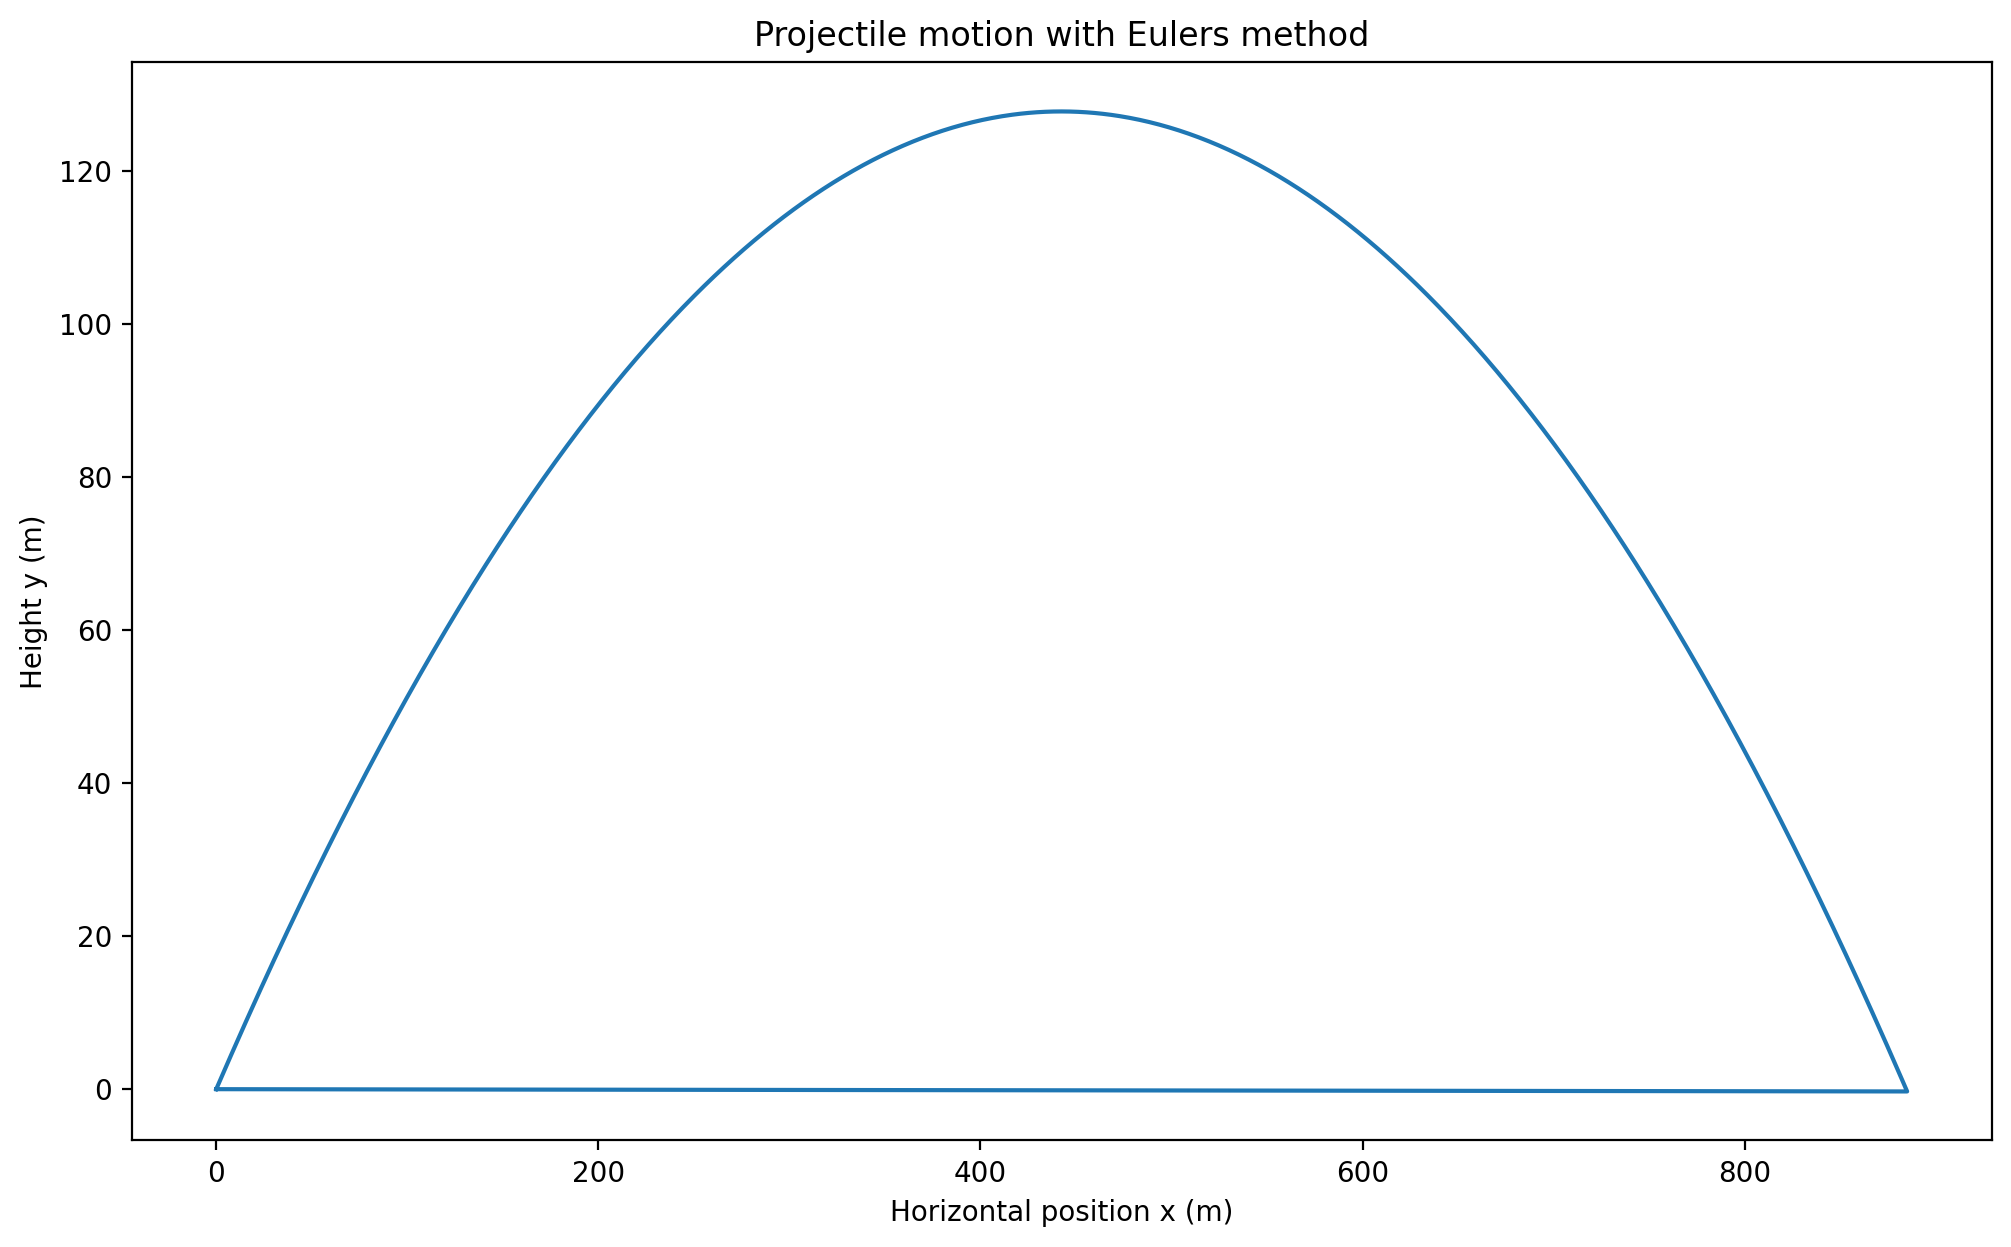

In [55]:
import numpy as np

# initialise variables for dt, g, and t_max (t_max is arbritrary, just needs to be longer han projectile flight time)
dt = 0.01  
g = 9.8
t_max = 15

# and initial conditions...
v0 = 100
theta = 30
theta_rad = np.radians(theta)
x0 = 0
y0 = 0


# number of timesteps required:
time_steps = int(t_max/dt) + 1      # +1 in order to include inital time t = 0

# initialise numpy arrays to hold x and y positions/velocities. we need np.zeros
x = np.zeros(time_steps)  # horizontal position
y = np.zeros(time_steps)  # vertical position
vx = np.zeros(time_steps) # horizontal velocity
vy = np.zeros(time_steps) # vertical velocity

# we can put our initial conditions in the arrays
x[0] = x0
y[0] = y0
vx[0] = v0*np.cos(theta_rad)    # initial velocities will be 100cos30 and 100sin30
vy[0] = v0*np.sin(theta_rad)

# okkk time for some Euler method

for i in range(time_steps - 1):
    vy[i+1] = vy[i] - dt * g   # from formula
    vx[i+1] = vx[i]         # no horizontal acceleration so vx is constant
    
    y[i+1] = y[i] + dt * vy[i]
    x[i+1] = x[i] + dt * vx[i]
    
    # need the loop to stop when the projectile hits the ground
    if y[i+1] < 0:
        t_travel = (i*dt + (i+1)*dt)/2   # take average of time points around projectile hitting the ground to find the time it spent travelling
        x_max = (x[i]+ x[i+1])/2   # similar idea for max horizontal distance
        
        break
        
max_height = np.max(y)

print('Maximum height:', max_height)
print('Maximum distance (x direction):', x_max)    
print('Travel time:', t_travel)

import matplotlib.pyplot as plt

plt.plot(x,y)
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Height y (m)')
plt.title('Projectile motion with Eulers method')


c) The total energy of the projectile at each point in time can be calculated as the sum of its kinetic and potential energy. Find the energy of the projectile (assuming a mass of 10kg) at each point in time in another array, and create a labelled plot of it as a function of time.

**In a text/markdown cell underneath, discuss what this plot is showing, and discuss what it should look like for the exact propagation of the projectile. Describe how the plot changes as the timestep, $\Delta t$ is changed, and why. What is the fundamental approximation made in the numerical solution we have implemented?** [9 marks]

Text(0.5, 1.0, 'Energy of the Projectile vs Flight Time')

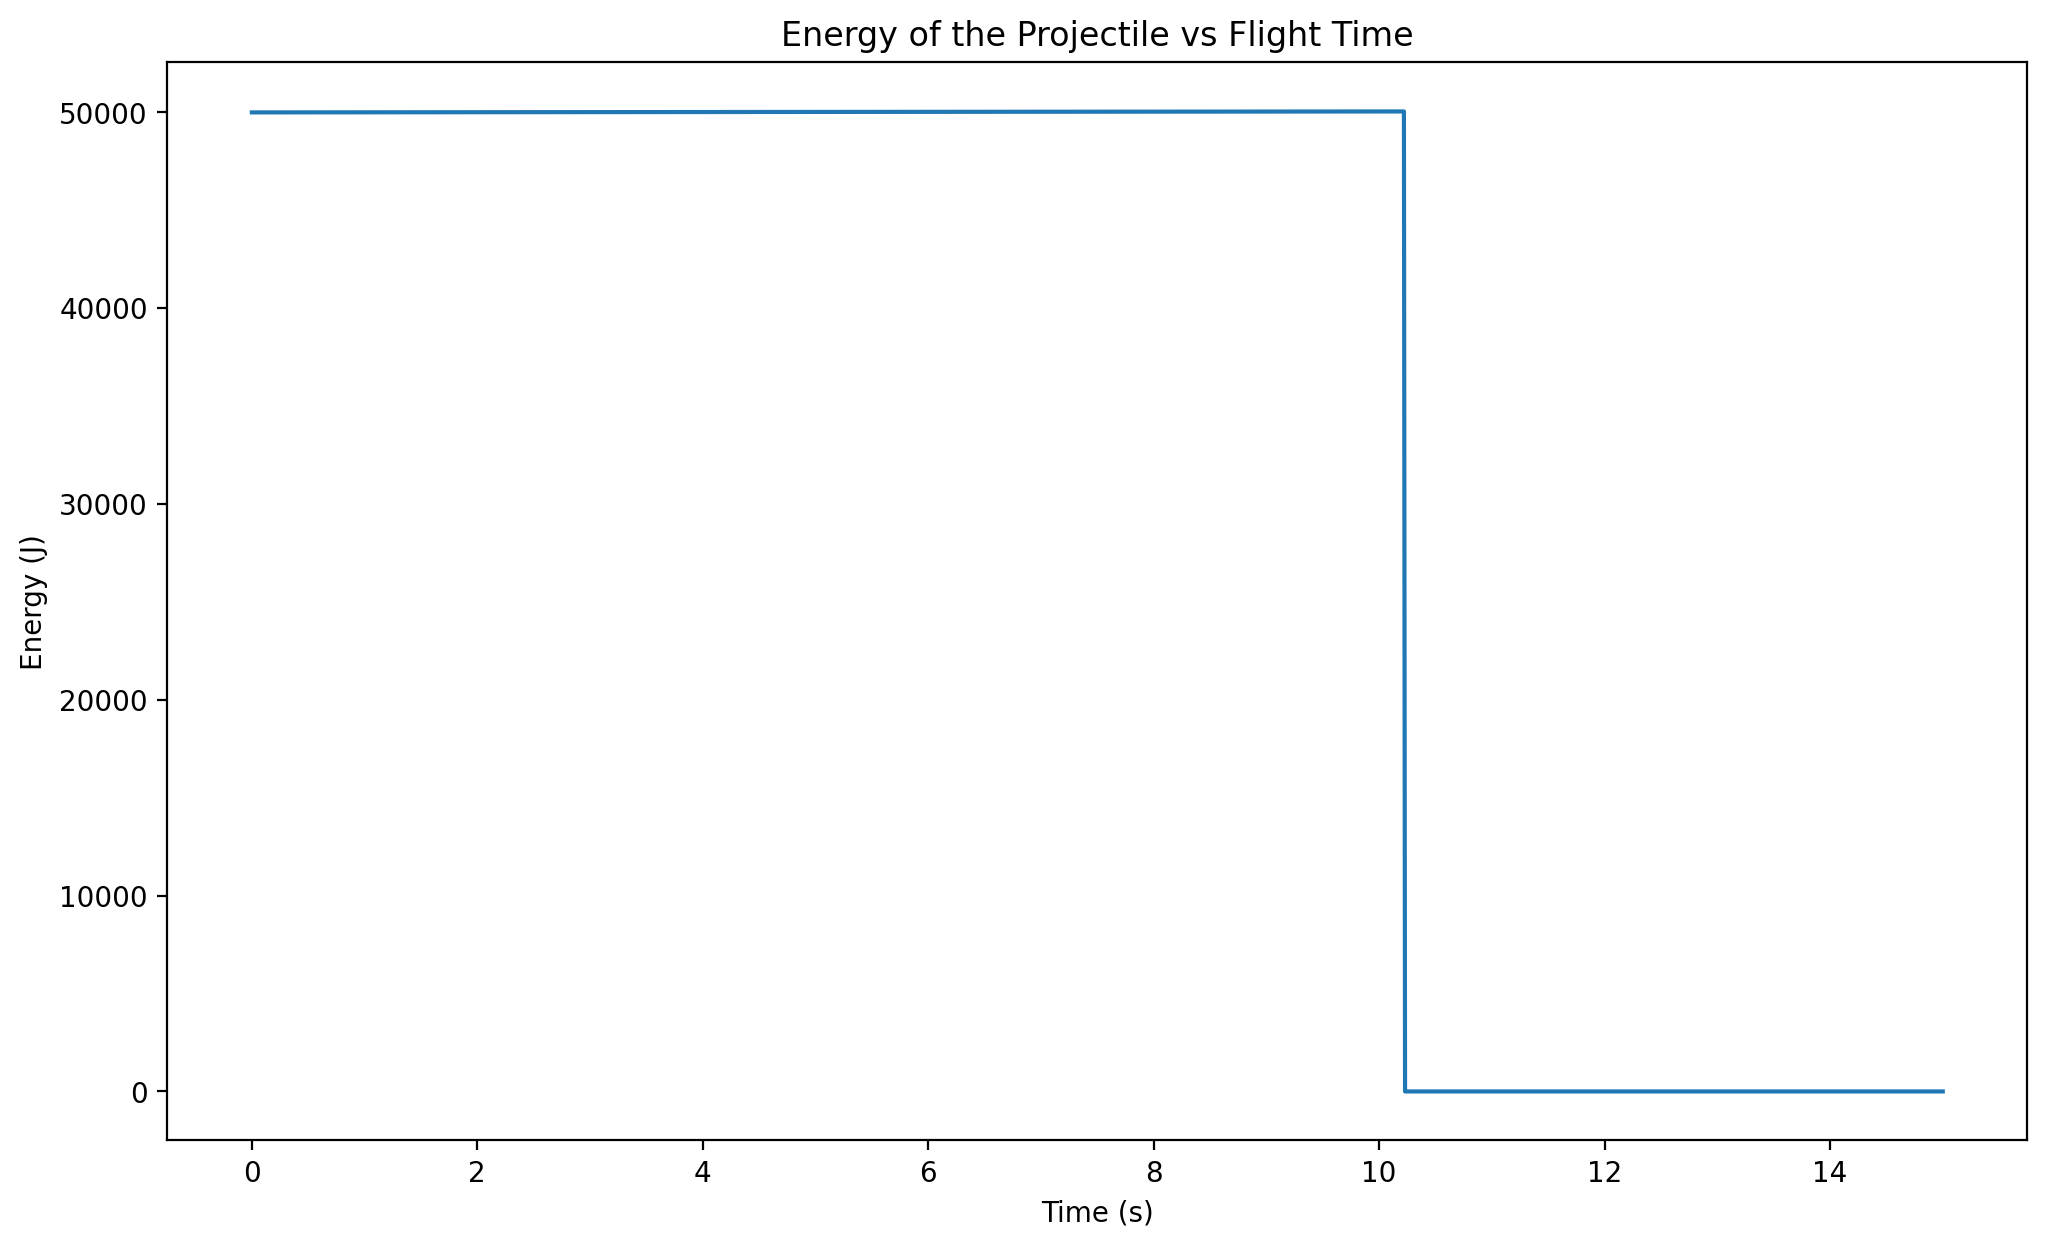

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# E_k = 1/2*mv**2, E_p = mgh
# => E = 1/2*mv**2 + mgy
# v = (vx**2 + vy**2)**1/2  => v**2 = (vx**2 + vy**2)

m = 10

E_total = (1/2 * m * (vx**2 + vy**2)) + m * g * y
time = np.arange(len(x)) * dt     # time is i * dt, and x,y,vx,vy are all arrays of length i, so we can use len(x)


plt.plot(time, E_total)
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy of the Projectile vs Flight Time')

What the plot is showing:

- The plot shows the total energy of the projectile over time.
- For the exact propagation of the projectile, the the total energy should be constant, so the plot should look flat as time increases.
- If the timestep dt were larger, the plot would show visible fluctuations because the Euler method uses approximations, and the accuracy of these approximations would decrease. As is, there are no visible fluctuations because the approximation is good enough that they do not show for tens of thousands of joules of energy.
- The fundamental approximation in the solution is that the derivative of a variable is assumed to be constant over the timestep dt, such that the next value can be estimated.

